# Combustíveis no Brasil
## Evolução dos preços e diferenças entre UFs, de 2015 a 2024
**Guilherme Daflon Goulart Costa**  
Linguagens de Programação · Projeto G1 · Tema 11 · 08/10/2026

### 1. Introdução
Quero entender onde a base apresenta os maiores preços e em quais períodos as médias mais oscilaram. Vou comparar UFs e regiões dentro de cada combustível e discutir a associação com inflação e petróleo. Os dados são simulados: as conclusões descrevem este exercício.

### 2. A base utilizada
Arquivo `simulacao_precos_combustiveis_brasil.csv`, do [repositório do professor Alexandre Louzada](https://github.com/AlexandreLouzada/Dados-Simulados-G1).

São 4.440 observações, de janeiro de 2015 a dezembro de 2024, em 20 UFs e cinco regiões. A fonte inclui gasolina, diesel, etanol, GNV e GLP, preços mínimo/médio/máximo, variação mensal, inflação, cotação do petróleo, consumo estimado e nível de preço.

A fonte não documenta as unidades físicas dos combustíveis ou do consumo. Por isso, uso os valores como informados e não trato as médias como preços oficiais nacionais. Inflação e petróleo também são atributos simulados por observação.

### 3. Leitura dos dados
**No Colab:** execute esta célula e envie o CSV quando solicitado. No repositório, o arquivo é encontrado automaticamente. Para repetir a análise, use **Executar tudo**. Não é preciso alterar um caminho do meu computador.

In [1]:
from pathlib import Path
import sys
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

try:
    import sqlalchemy
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'SQLAlchemy>=2,<3'])
from sqlalchemy import create_engine, text
from hashlib import sha256
from io import BytesIO

ARQUIVO = 'simulacao_precos_combustiveis_brasil.csv'
candidatos = [Path('dados') / ARQUIVO, Path('../dados') / ARQUIVO, Path(ARQUIVO)]
caminho = next((x for x in candidatos if x.exists()), None)
if caminho is None:
    try:
        from google.colab import files
    except ImportError:
        raise FileNotFoundError(f'Coloque {ARQUIVO} na pasta dados/ ou ao lado do notebook.')
    enviados = files.upload()
    if len(enviados) != 1:
        raise ValueError('Envie somente o CSV desta atividade e execute novamente a célula.')
    conteudo = next(iter(enviados.values()))
    PASTA_PROJETO = Path.cwd()
else:
    conteudo = caminho.read_bytes()
    PASTA_PROJETO = caminho.resolve().parent.parent if caminho.parent.name == 'dados' else Path.cwd()
base = pd.read_csv(BytesIO(conteudo), encoding='utf-8-sig')
print(f'{len(base):,} observações | {len(base.columns)} colunas')
display(base.head())

Matplotlib is building the font cache; this may take a moment.


4,440 observações | 14 colunas


,ano,mes,data,regiao,uf,combustivel,preco_medio,preco_minimo,preco_maximo,variacao_mensal,inflacao,cotacao_petroleo,consumo_estimado,nivel_preco
0,2015,1,2015-01-01,Norte,AM,Gasolina,7.49,6.90,8.47,6.75,2.89,78.31,179221,Médio
1,2015,1,2015-01-01,Norte,PA,Diesel,3.80,3.50,4.30,1.67,10.94,95.35,50575,Alto
2,2015,1,2015-01-01,Norte,PA,GNV,4.83,4.45,5.46,-2.85,2.60,47.82,171715,Médio
3,2015,1,2015-01-01,Norte,RO,Gasolina,7.14,6.57,8.07,-4.83,6.99,95.94,195652,Crítico
4,2015,1,2015-01-01,Norte,TO,Diesel,3.30,3.03,3.73,6.30,3.02,45.92,49432,Médio


### 4. Limpeza e conferência
Antes de calcular as médias, confiro tipos, valores ausentes, duplicatas, datas e intervalos de preço. Chaves repetidas por mês, UF e combustível não serão eliminadas como se fossem linhas idênticas.

In [2]:
base.info()
diagnostico = pd.Series({
    'Valores ausentes': int(base.isna().sum().sum()),
    'Linhas inteiras duplicadas': int(base.duplicated().sum()),
    'Ocorrências adicionais da mesma chave': int(base.duplicated(['data', 'uf', 'combustivel']).sum()),
    'UFs': base.uf.nunique(),
    'Regiões': base.regiao.nunique(),
    'Combustíveis': base.combustivel.nunique()
}, name='Quantidade')
display(diagnostico.to_frame())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ano               4440 non-null   int64  
 1   mes               4440 non-null   int64  
 2   data              4440 non-null   object 
 3   regiao            4440 non-null   object 
 4   uf                4440 non-null   object 
 5   combustivel       4440 non-null   object 
 6   preco_medio       4440 non-null   float64
 7   preco_minimo      4440 non-null   float64
 8   preco_maximo      4440 non-null   float64
 9   variacao_mensal   4440 non-null   float64
 10  inflacao          4440 non-null   float64
 11  cotacao_petroleo  4440 non-null   float64
 12  consumo_estimado  4440 non-null   int64  
 13  nivel_preco       4440 non-null   object 
dtypes: float64(6), int64(3), object(5)
memory usage: 485.8+ KB


,Quantidade
Valores ausentes,0
Linhas inteiras duplicadas,0
Ocorrências adicionais da mesma chave,503
UFs,20
Regiões,5
Combustíveis,5


In [3]:
"""Preparação, indicadores e gráficos utilizados no dashboard."""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

MESES = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
COR = '#007F78'

def preparar(base):
    dados = base.copy()
    dados.columns = dados.columns.str.strip()
    obrigatorias = ['ano', 'mes', 'data', 'regiao', 'uf', 'combustivel', 'preco_medio',
                    'preco_minimo', 'preco_maximo', 'variacao_mensal', 'inflacao',
                    'cotacao_petroleo', 'consumo_estimado', 'nivel_preco']
    faltantes = set(obrigatorias) - set(dados.columns)
    if faltantes:
        raise ValueError(f'Colunas ausentes: {sorted(faltantes)}')
    if dados[obrigatorias].isna().any().any():
        raise ValueError('A base contém valores ausentes. Revise a origem antes da análise.')
    dados['data'] = pd.to_datetime(dados['data'], errors='raise')
    for coluna in ['regiao', 'uf', 'combustivel', 'nivel_preco']:
        dados[coluna] = dados[coluna].str.strip()
    for coluna in set(obrigatorias) - {'data', 'regiao', 'uf', 'combustivel', 'nivel_preco'}:
        dados[coluna] = pd.to_numeric(dados[coluna], errors='raise')
        if not np.isfinite(dados[coluna]).all():
            raise ValueError(f'Valor não finito em {coluna}.')
    valido = ((dados['data'].dt.year == dados['ano']) & (dados['data'].dt.month == dados['mes'])
              & (dados['preco_minimo'] > 0) & (dados['preco_minimo'] <= dados['preco_medio'])
              & (dados['preco_medio'] <= dados['preco_maximo']) & (dados['consumo_estimado'] >= 0))
    if not valido.all():
        raise ValueError('Há datas ou intervalos de preço inconsistentes.')
    # Chaves repetidas não significam linhas idênticas: as observações são preservadas.
    dados['amplitude_preco'] = dados['preco_maximo'] - dados['preco_minimo']
    dados['amplitude_pct'] = dados['amplitude_preco'] / dados['preco_medio'] * 100
    return dados.sort_values(['data', 'uf', 'combustivel']).reset_index(drop=True)

def serie_mensal(dados):
    if dados.empty:
        return pd.DataFrame(columns=['preco_medio', 'n', 'variacao_calculada'])
    mensal = dados.groupby(dados['data'].dt.to_period('M')).agg(
        preco_medio=('preco_medio', 'mean'), n=('preco_medio', 'size'))
    calendario = pd.period_range(mensal.index.min(), mensal.index.max(), freq='M')
    mensal = mensal.reindex(calendario)
    # fill_method=None evita preencher lacunas ou comparar meses não consecutivos.
    mensal['variacao_calculada'] = mensal['preco_medio'].pct_change(fill_method=None) * 100
    mensal.index = mensal.index.to_timestamp()
    mensal.index.name = 'data'
    return mensal

def ranking(dados, campo):
    return dados.groupby(campo).agg(preco_medio=('preco_medio', 'mean'),
                                   n=('preco_medio', 'size')).sort_values('preco_medio', ascending=False)

def correlacao(dados, coluna):
    pares = dados[['preco_medio', coluna]].dropna()
    n = len(pares)
    if n < 3 or pares.nunique().min() < 2:
        return np.nan, n
    return pares['preco_medio'].corr(pares[coluna]), n

def moeda(valor):
    return f'R$ {valor:,.2f}'.replace(',', '_').replace('.', ',').replace('_', '.')

def numero(valor, casas=0):
    return f'{valor:,.{casas}f}'.replace(',', '_').replace('.', ',').replace('_', '.')

In [4]:
dados = preparar(base)
print('Datas compatíveis com ano/mês e preços dentro do intervalo informado.')
print('Nenhuma linha foi excluída:', len(dados) == len(base))
display(dados.describe().round(2))
repetidas = dados[dados.duplicated(['data', 'uf', 'combustivel'], keep=False)]
display(repetidas.head(8))

Datas compatíveis com ano/mês e preços dentro do intervalo informado.
Nenhuma linha foi excluída: True


,ano,mes,data,preco_medio,preco_minimo,preco_maximo,variacao_mensal,inflacao,cotacao_petroleo,consumo_estimado,amplitude_preco,amplitude_pct
count,4440.00,4440.00,4440,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00
mean,2019.50,6.50,2019-12-16 10:48:00,5.51,5.07,6.23,0.51,7.02,77.40,126397.95,1.16,21.00
min,2015.00,1.00,2015-01-01 00:00:00,3.00,2.76,3.39,-15.61,2.00,45.01,5013.00,0.63,20.71
25%,2017.00,3.75,2017-06-23 12:00:00,4.24,3.90,4.79,-2.13,4.51,61.10,63811.50,0.89,20.95
50%,2019.50,6.50,2019-12-16 12:00:00,5.53,5.08,6.24,0.50,7.01,77.76,125770.00,1.16,21.00
75%,2022.00,9.25,2022-06-08 12:00:00,6.78,6.24,7.66,3.21,9.48,93.52,187888.50,1.42,21.05
max,2024.00,12.00,2024-12-01 00:00:00,8.00,7.36,9.04,14.73,12.00,109.98,249977.00,1.68,21.33
std,2.87,3.45,NaN,1.46,1.34,1.65,4.02,2.88,18.87,71390.34,0.31,0.08


,ano,mes,data,regiao,uf,combustivel,preco_medio,preco_minimo,preco_maximo,variacao_mensal,inflacao,cotacao_petroleo,consumo_estimado,nivel_preco,amplitude_preco,amplitude_pct
12,2015,1,2015-01-01,Sudeste,MG,Diesel,4.03,3.71,4.55,-4.06,10.94,48.80,50878,Alto,0.84,20.843672
13,2015,1,2015-01-01,Sudeste,MG,Diesel,7.42,6.83,8.39,1.26,3.54,72.92,129817,Médio,1.56,21.024259
29,2015,1,2015-01-01,Sul,RS,GNV,3.35,3.09,3.79,-1.77,11.98,77.50,32495,Médio,0.70,20.895522
30,2015,1,2015-01-01,Sul,RS,GNV,6.87,6.32,7.76,2.05,5.47,55.60,202340,Alto,1.44,20.960699
31,2015,1,2015-01-01,Sul,SC,GNV,5.17,4.76,5.85,2.80,2.32,100.96,237557,Médio,1.09,21.083172
32,2015,1,2015-01-01,Sul,SC,GNV,3.31,3.04,3.74,1.62,5.64,102.26,194104,Baixo,0.70,21.148036
44,2015,2,2015-02-01,Sudeste,ES,GLP,3.40,3.13,3.84,4.62,7.64,48.10,18921,Médio,0.71,20.882353
45,2015,2,2015-02-01,Sudeste,ES,GLP,3.47,3.19,3.92,1.40,7.23,88.99,78109,Crítico,0.73,21.037464


A conferência encontrou zero valores ausentes e zero linhas inteiras duplicadas. Há **503 ocorrências adicionais da mesma chave**, com valores diferentes; mantive todas e fiz as comparações por média. Cada observação terá sua própria identificação no banco.

A cobertura é desigual entre UFs e combustíveis. Uma diferença entre médias pode refletir também a composição das observações.

### 5. Engenharia de atributos e persistência
Criei a amplitude entre os preços máximo e mínimo e sua proporção em relação ao preço médio. A variação temporal será recalculada após o agrupamento mensal, sem preencher meses ausentes.

Para a funcionalidade avançada, salvo as observações em SQLite e faço a leitura pelo SQLAlchemy. A assinatura do conteúdo evita importar a mesma base novamente.

In [5]:
display(dados[['data', 'uf', 'combustivel', 'preco_medio', 'amplitude_preco', 'amplitude_pct']].head())
PASTA_BANCO = PASTA_PROJETO / 'database'
PASTA_BANCO.mkdir(exist_ok=True)
engine = create_engine(f'sqlite:///{PASTA_BANCO / "notebook_combustiveis.db"}')
assinatura = sha256(conteudo).hexdigest()
with engine.begin() as conn:
    conn.execute(text('CREATE TABLE IF NOT EXISTS origem (id INTEGER PRIMARY KEY, sha256 TEXT NOT NULL)'))
    anterior = conn.execute(text('SELECT sha256 FROM origem WHERE id = 1')).scalar()
    existe = conn.execute(text("SELECT name FROM sqlite_master WHERE type='table' AND name='observacoes'")).scalar()
    if anterior != assinatura or not existe:
        persistidos = dados.copy()
        persistidos.index = range(1, len(persistidos) + 1)
        persistidos.to_sql('observacoes', conn, if_exists='replace', index=True, index_label='id_observacao')
        conn.execute(text('CREATE UNIQUE INDEX IF NOT EXISTS idx_observacao ON observacoes(id_observacao)'))
        conn.execute(text('DELETE FROM origem'))
        conn.execute(text('INSERT INTO origem VALUES (1, :hash)'), {'hash': assinatura})
    leitura_sql = pd.read_sql_query(text('SELECT * FROM observacoes ORDER BY id_observacao'), conn)
    resumo_sql = pd.read_sql_query(text('SELECT combustivel, COUNT(*) AS observacoes, AVG(preco_medio) AS media FROM observacoes GROUP BY combustivel'), conn)
engine.dispose()
dados = preparar(leitura_sql)
print('Registros lidos do SQLite:', len(dados))
display(resumo_sql.round(3))

,data,uf,combustivel,preco_medio,amplitude_preco,amplitude_pct
0,2015-01-01,AM,Gasolina,7.49,1.57,20.961282
1,2015-01-01,BA,Etanol,6.49,1.36,20.955316
2,2015-01-01,BA,Gasolina,7.05,1.48,20.992908
3,2015-01-01,CE,GNV,3.10,0.65,20.967742
4,2015-01-01,CE,Gasolina,6.18,1.30,21.035599


Registros lidos do SQLite: 4440


,combustivel,observacoes,media
0,Diesel,892,5.444
1,Etanol,861,5.562
2,GLP,900,5.555
3,GNV,912,5.475
4,Gasolina,875,5.534


### 6. Análise exploratória
Primeiro observo a distribuição da base. Depois uso gasolina como recorte principal: isso facilita comparar UFs e períodos sem misturar combustíveis com unidades físicas não confirmadas.

In [6]:
display(dados.groupby('combustivel').agg(observacoes=('preco_medio', 'size'),
    ufs=('uf', 'nunique'), meses=('data', 'nunique'), media=('preco_medio', 'mean')).round(2))
display(dados.groupby('regiao').agg(observacoes=('preco_medio', 'size'), ufs=('uf', 'nunique')))
print('Valores distintos de inflação e petróleo dentro de cada mês:')
display(dados.groupby('data')[['inflacao', 'cotacao_petroleo']].nunique().head())
COMBUSTIVEL = 'Gasolina'  # Troque aqui para repetir as análises de um combustível.
recorte = dados[dados.combustivel == COMBUSTIVEL].copy()
mensal = serie_mensal(recorte)
por_uf = ranking(recorte, 'uf')
por_regiao = ranking(recorte, 'regiao')

,observacoes,ufs,meses,media
combustivel,,,,
Diesel,892,20,120,5.44
Etanol,861,20,120,5.56
GLP,900,20,120,5.56
GNV,912,20,120,5.48
Gasolina,875,20,120,5.53


,observacoes,ufs
regiao,,
Centro-Oeste,600,4
Nordeste,960,5
Norte,600,4
Sudeste,1560,4
Sul,720,3


Valores distintos de inflação e petróleo dentro de cada mês:


,inflacao,cotacao_petroleo
data,,
2015-01-01,36,37
2015-02-01,36,36
2015-03-01,36,37
2015-04-01,36,37
2015-05-01,36,37


### 7. Indicadores
As médias são simples por observação. A soma de consumo usa somente o combustível escolhido e mantém a unidade não documentada da fonte. A maior oscilação é escolhida pelo valor absoluto, conservando o sinal.

In [7]:
variacoes = mensal.variacao_calculada.dropna()
mes_maior = variacoes.abs().idxmax()
primeiro, ultimo = mensal.preco_medio.dropna().iloc[[0, -1]]
kpis = pd.Series({
    'Combustível': COMBUSTIVEL,
    'Observações': len(recorte),
    'Preço médio no recorte': moeda(recorte.preco_medio.mean()),
    'UF com maior média': por_uf.index[0],
    'Média dessa UF': moeda(por_uf.iloc[0].preco_medio),
    'Região com maior média': por_regiao.index[0],
    'Maior oscilação mensal': f'{variacoes.loc[mes_maior]:.2f}% ({mes_maior:%m/%Y})',
    'Consumo estimado - soma': int(recorte.consumo_estimado.sum()),
    'Primeiro/último mês': f'{(ultimo/primeiro-1)*100:.2f}%',
    'Desvio padrão das variações': f'{variacoes.std():.2f} pontos percentuais'
}, name='Resultado')
display(kpis.to_frame())
display(por_uf.round(3))

,Resultado
Combustível,Gasolina
Observações,875
Preço médio no recorte,"R$ 5,53"
UF com maior média,SP
Média dessa UF,"R$ 5,93"
Região com maior média,Sul
Maior oscilação mensal,38.05% (10/2020)
Consumo estimado - soma,109068228
Primeiro/último mês,-2.45%
Desvio padrão das variações,14.24 pontos percentuais


,preco_medio,n
uf,,
SP,5.929,76
TO,5.843,18
BA,5.819,58
SC,5.816,48
AM,5.775,28
RS,5.682,55
PB,5.681,21
MA,5.566,20
PE,5.552,46


### 8. Visualizações
Uso Matplotlib e Seaborn para observar a evolução, os contrastes geográficos, os meses de maior preço e as associações estatísticas. Os arquivos PNG também ficam na pasta `imagens/`.

In [8]:
def estilo():
    sns.set_theme(style='whitegrid', palette=['#007F78', '#ED9A37', '#405F91', '#9869A6', '#D46152'])
    plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                         'axes.titleweight': 'bold', 'figure.dpi': 110})

def linha(dados, combustivel):
    serie = serie_mensal(dados)
    fig, ax = plt.subplots(figsize=(10, 4.3), layout='constrained')
    ax.plot(serie.index, serie['preco_medio'], color=COR, linewidth=2)
    ax.set(title=f'{combustivel}: preço médio mensal', xlabel='Período', ylabel='Preço informado (R$)')
    return fig

def barras(dados, campo, titulo):
    tabela = ranking(dados, campo).sort_values('preco_medio')
    fig, ax = plt.subplots(figsize=(10, max(3.5, len(tabela) * .28)), layout='constrained')
    ax.barh(tabela.index, tabela['preco_medio'], color=COR)
    ax.bar_label(ax.containers[0], fmt='%.2f', padding=3, fontsize=9)
    ax.set(title=titulo, xlabel='Preço médio informado (R$)', ylabel='')
    ax.set_xlim(0, tabela['preco_medio'].max() * 1.15)
    return fig

def mapa_mensal(dados, combustivel):
    tabela = dados.pivot_table(index='ano', columns='mes', values='preco_medio', aggfunc='mean')
    tabela = tabela.reindex(columns=range(1, 13))
    fig, ax = plt.subplots(figsize=(11, max(3, len(tabela) * .5)), layout='constrained')
    sns.heatmap(tabela, annot=True, fmt='.2f', cmap='YlOrRd', mask=tabela.isna(),
                cbar_kws={'label': 'Preço informado (R$)'}, ax=ax, xticklabels=MESES)
    ax.set(title=f'{combustivel}: médias por ano e mês', xlabel='Mês', ylabel='Ano')
    return fig

def dispersao(dados, coluna, combustivel):
    rotulo = {'inflacao': 'Inflação informada na simulação',
              'cotacao_petroleo': 'Cotação do petróleo informada na simulação'}[coluna]
    r, n = correlacao(dados, coluna)
    fig, ax = plt.subplots(figsize=(9, 4.5), layout='constrained')
    sns.scatterplot(data=dados, x=coluna, y='preco_medio', hue='regiao', alpha=.65, s=32, ax=ax)
    ax.set(title=f'{combustivel}: associação com {coluna.replace("_", " ")} | r={r:.3f}, n={n}',
           xlabel=rotulo, ylabel='Preço informado (R$)')
    ax.legend(title='Região', fontsize=8)
    return fig


estilo()
PASTA_IMAGENS = PASTA_PROJETO / 'imagens'
PASTA_IMAGENS.mkdir(exist_ok=True)
def exibir_salvar(fig, nome):
    fig.savefig(PASTA_IMAGENS / nome, dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)

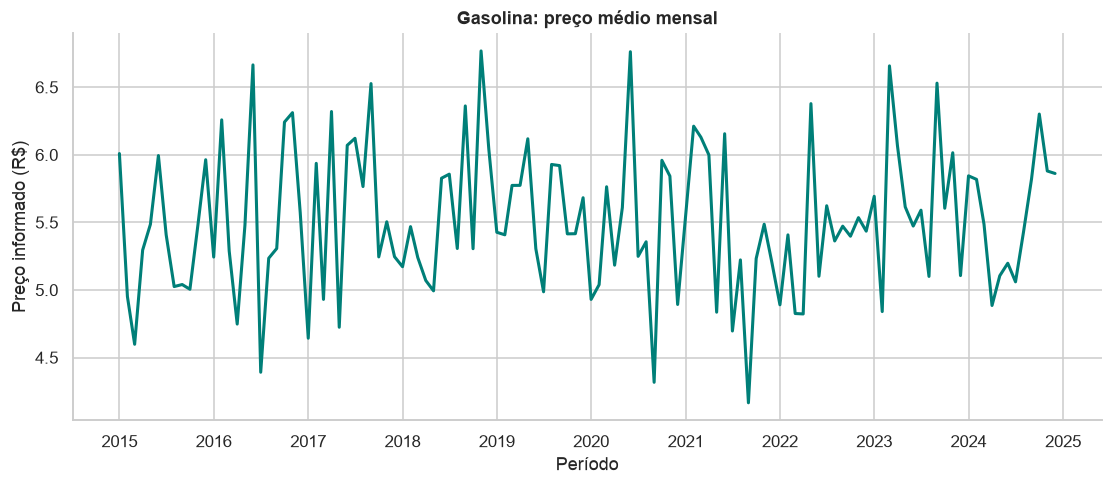

,preco_medio,n,variacao_calculada
data,,,
2020-10-01,5.959,10,38.046
2023-03-01,6.658,9,37.557
2022-05-01,6.378,6,32.262
2017-06-01,6.070,6,28.493
2017-04-01,6.320,4,28.195


In [9]:
exibir_salvar(linha(recorte, COMBUSTIVEL), '01_evolucao_gasolina.png')
display(mensal.sort_values('variacao_calculada', ascending=False).head(5).round(3))

Na gasolina, a média de janeiro de 2015 a dezembro de 2024 caiu **2,45%** ao comparar apenas o primeiro e o último mês. A maior oscilação mensal foi uma alta de **38,05% em outubro de 2020**. São oscilações da simulação, sem atribuição a um acontecimento real.

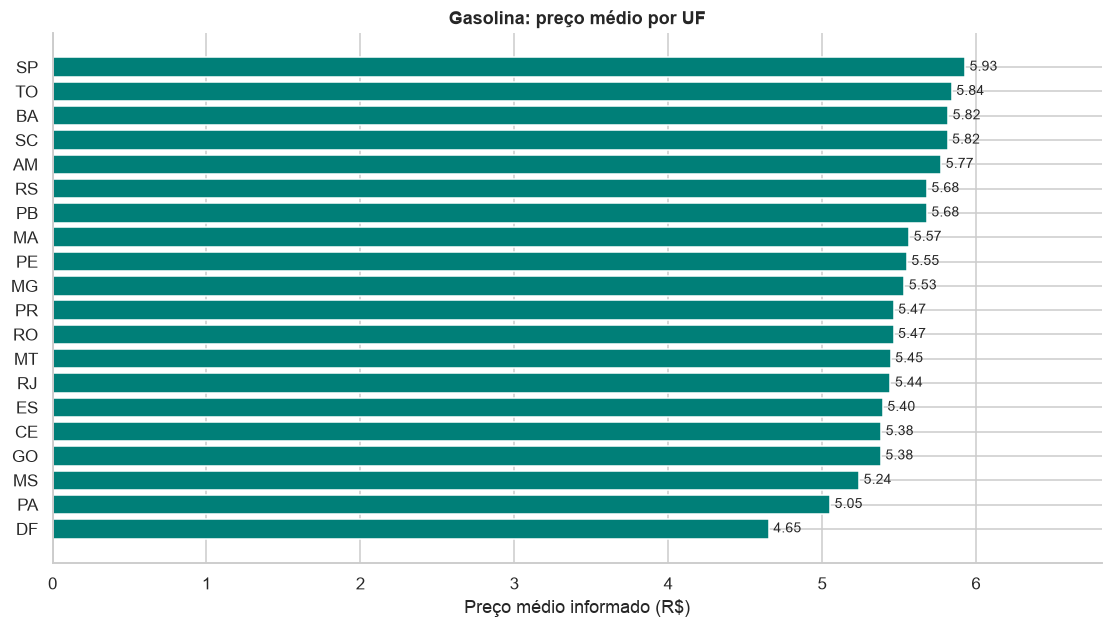

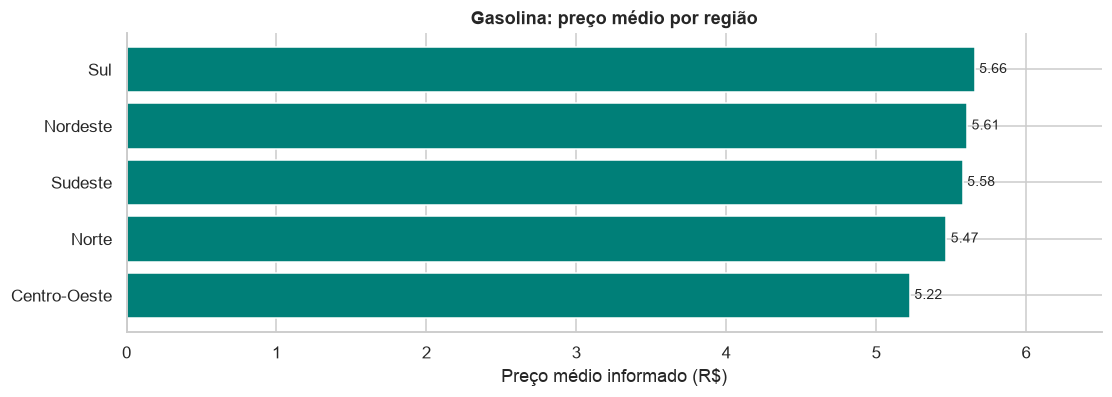

In [10]:
exibir_salvar(barras(recorte, 'uf', f'{COMBUSTIVEL}: preço médio por UF'), '02_ufs_gasolina.png')
exibir_salvar(barras(recorte, 'regiao', f'{COMBUSTIVEL}: preço médio por região'), '03_regioes_gasolina.png')

Na média das observações de gasolina, **SP** ficou no topo (R$ 5,93) e o **DF** apresentou o menor valor (R$ 4,65). O **Sul** teve a maior média regional. Esses rankings usam todas as observações disponíveis, com coberturas diferentes.

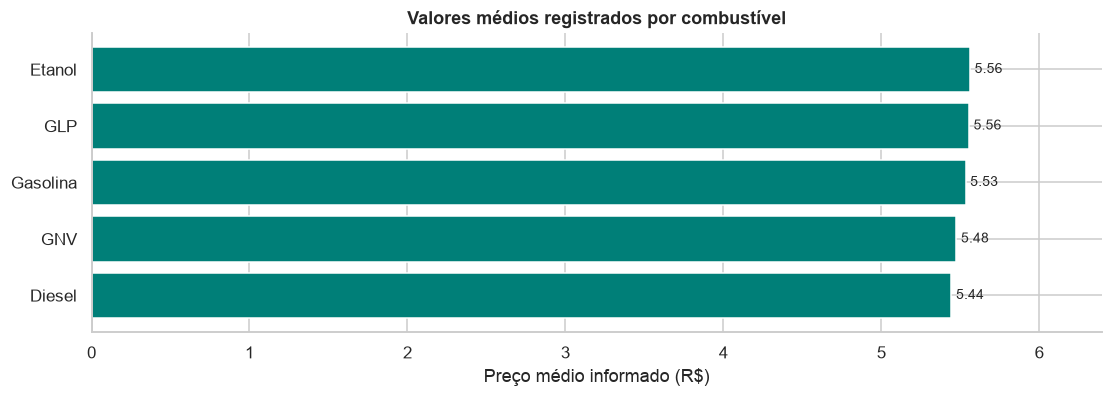

,Variação entre médias anuais de 2015 e 2024 (%)
combustivel,
GLP,4.96
Gasolina,3.62
Etanol,3.34
GNV,1.55
Diesel,-2.50


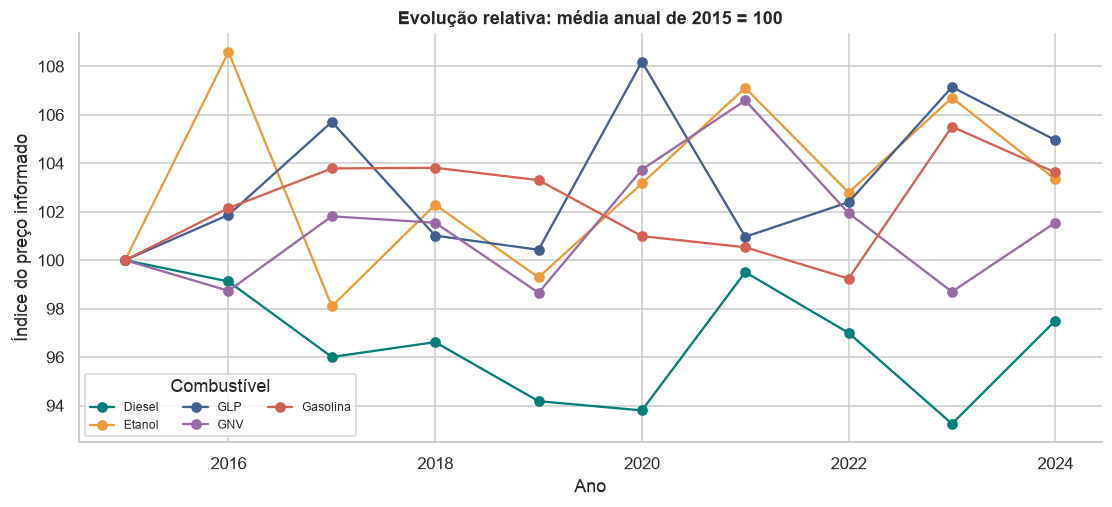

In [11]:
exibir_salvar(barras(dados, 'combustivel', 'Valores médios registrados por combustível'), '04_combustiveis.png')
anual = dados.groupby(['ano', 'combustivel']).preco_medio.mean().unstack('combustivel')
crescimento = ((anual.loc[2024] / anual.loc[2015] - 1) * 100).sort_values(ascending=False)
display(crescimento.rename('Variação entre médias anuais de 2015 e 2024 (%)').round(2).to_frame())
indice = anual.div(anual.loc[2015]).mul(100)
fig, ax = plt.subplots(figsize=(10, 4.5), layout='constrained')
indice.plot(ax=ax, marker='o')
ax.set(title='Evolução relativa: média anual de 2015 = 100', xlabel='Ano', ylabel='Índice do preço informado')
ax.legend(title='Combustível', ncol=3, fontsize=8)
exibir_salvar(fig, '05_evolucao_relativa.png')

O **etanol** tem o maior valor médio registrado (R$ 5,56), mas a comparação bruta não indica economia entre combustíveis. Na evolução relativa das **médias anuais**, o GLP apresentou a maior alta entre 2015 e 2024 (**4,96%**) e o diesel caiu **2,50%**. A gasolina subiu **3,62%** nesse critério anual. Isso difere da comparação entre janeiro e dezembro porque as bases de cálculo são distintas.

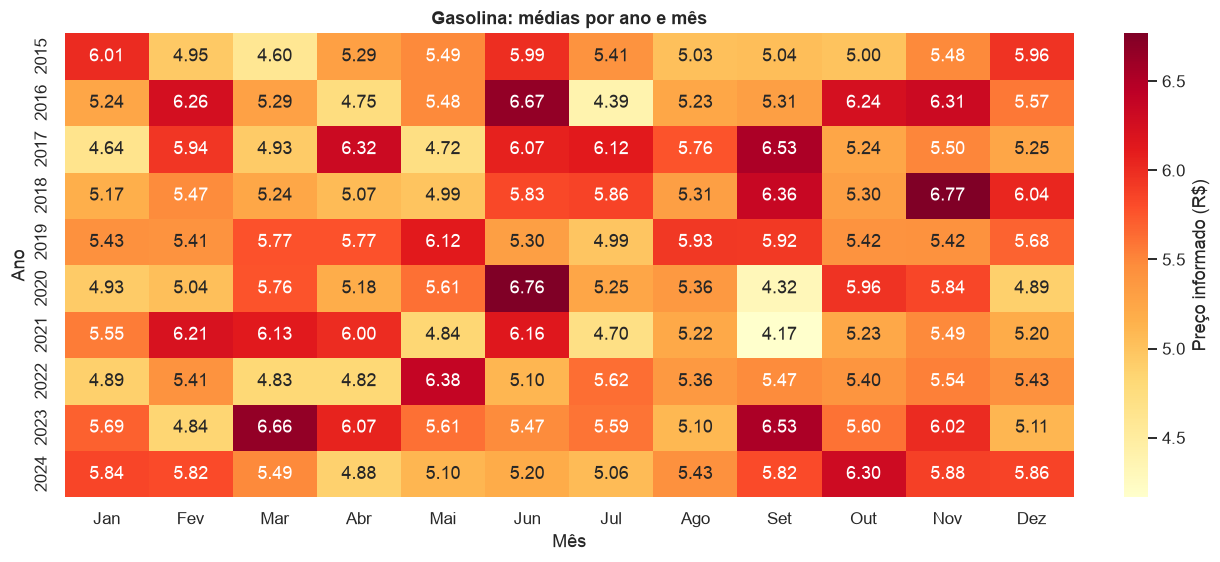

Meses com as maiores médias de gasolina:


,preco_medio,n
data,,
2018-11-01,6.768,6
2020-06-01,6.762,8
2016-06-01,6.665,8
2023-03-01,6.658,9
2023-09-01,6.530,7


,Desvio padrão (p.p.),Variações calculadas
ano,,
2015,10.01,11
2016,17.95,12
2017,19.57,12
2018,13.26,12
2019,8.80,12
2020,18.03,12
2021,17.09,12
2022,12.91,12
2023,16.91,12


In [12]:
exibir_salvar(mapa_mensal(recorte, COMBUSTIVEL), '06_heatmap_gasolina.png')
print('Meses com as maiores médias de gasolina:')
display(mensal.nlargest(5, 'preco_medio')[['preco_medio', 'n']].round(3))
volatilidade = mensal.assign(ano=mensal.index.year).groupby('ano').variacao_calculada.agg(['std', 'count'])
display(volatilidade.rename(columns={'std':'Desvio padrão (p.p.)', 'count':'Variações calculadas'}).round(2))

O heatmap ajuda a localizar os valores maiores, enquanto o desvio padrão das variações mostra a dispersão das mudanças mensais. Uma alta média de preço e uma alta volatilidade são medidas diferentes.

Na gasolina, novembro de 2018 teve a maior média mensal (**R$ 6,77**). O ano de 2017 apresentou a maior dispersão das variações (**19,57 pontos percentuais**). Uso esses períodos para priorizar a leitura dos gráficos; não atribuo os picos a eventos reais.

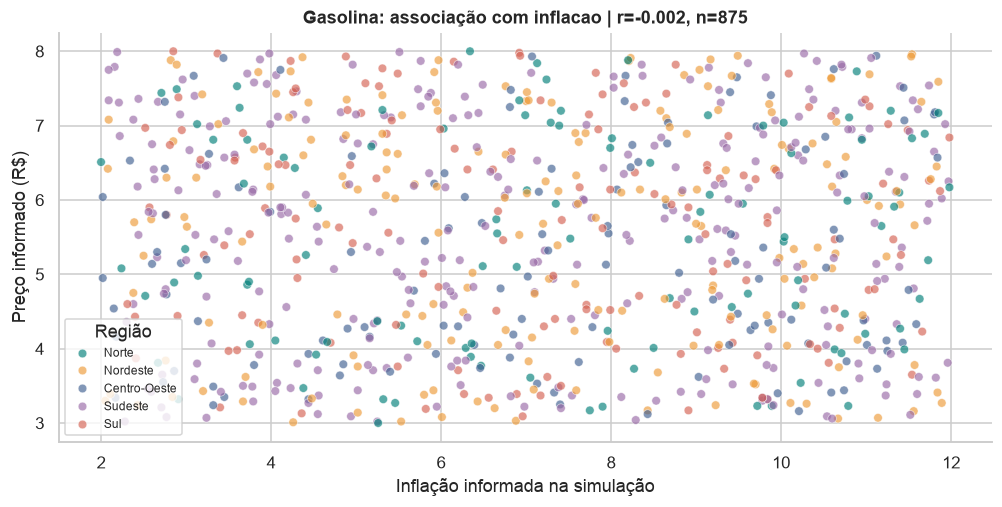

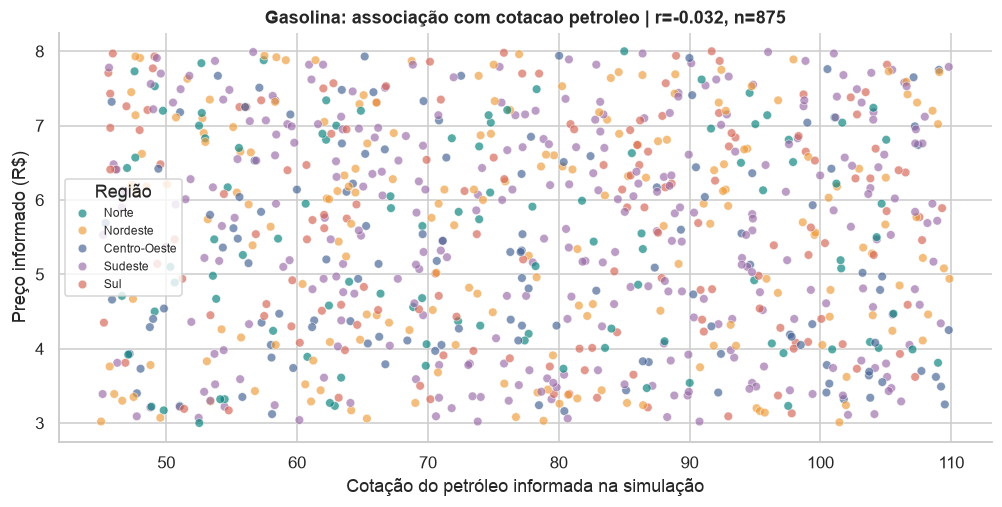

,Variável,Pearson r,Pares
0,inflacao,-0.0019,875
1,cotacao_petroleo,-0.0317,875


Correlação também por combustível:


,Combustível,Inflação,Petróleo,n
0,Diesel,-0.0224,-0.0219,892
1,Etanol,-0.0058,-0.0369,861
2,GLP,0.0039,0.0614,900
3,GNV,-0.0203,0.0332,912
4,Gasolina,-0.0019,-0.0317,875


In [13]:
associacoes = []
for campo, arquivo in [('inflacao', '07_inflacao_gasolina.png'), ('cotacao_petroleo', '08_petroleo_gasolina.png')]:
    r, n = correlacao(recorte, campo)
    associacoes.append({'Variável': campo, 'Pearson r': r, 'Pares': n})
    exibir_salvar(dispersao(recorte, campo, COMBUSTIVEL), arquivo)
display(pd.DataFrame(associacoes).round(4))
print('Correlação também por combustível:')
display(pd.DataFrame([{'Combustível': f, 'Inflação': correlacao(g,'inflacao')[0],
 'Petróleo': correlacao(g,'cotacao_petroleo')[0], 'n':len(g)} for f,g in dados.groupby('combustivel')]).round(4))

Na gasolina, a correlação de Pearson foi **−0,0019 com inflação** e **−0,0317 com petróleo**, usando 875 pares. Os valores próximos de zero indicam pouca associação linear nesta base. Não concluo que essas variáveis não influenciam preços no mundo real: são atributos simulados e não séries econômicas oficiais.

### 9. Interpretação
O resultado que mais chama minha atenção é a distância entre a oscilação mensal e a mudança anual. Uma alta de um mês não resume dez anos de preços.

Para acompanhar a simulação, eu começaria pela gasolina, compararia a mesma UF ao longo do tempo e verificaria a cobertura antes de interpretar um ranking. SP teve a maior média neste conjunto, mas isso não permite afirmar que tenha sido sempre a UF mais cara.

O dashboard permite repetir essa leitura com filtros por ano, mês, região, UF, combustível e nível de preço. Ele recalcula KPIs e associações e permite baixar o recorte. [Abrir o código do dashboard](https://github.com/daflon-prognum/lasalle/tree/main/projeto-precos-combustiveis).

### 10. Conclusão
A análise mostrou diferenças entre UFs e oscilações mensais relevantes na simulação. O crescimento entre médias anuais foi modesto e variou conforme o combustível; as correlações com inflação e petróleo ficaram próximas de zero.

Aprendi a preservar observações distintas, calcular variações sem atravessar lacunas e separar o que o dado mostra do que ele não permite afirmar. Pandas organizou as análises, Matplotlib e Seaborn produziram os gráficos, e SQLAlchemy com SQLite garantiu a leitura da base persistida. O próximo passo, fora do escopo desta entrega, seria usar dados oficiais com unidades e cobertura documentadas.

**Referências:** [Dados do professor](https://github.com/AlexandreLouzada/Dados-Simulados-G1) · [Orientações G1](https://docs.google.com/document/d/1n0XkgQHGBB8guzgcipMufNEmHTw7bvas5vqTbjGYabo/edit) · [Projeto no GitHub](https://github.com/daflon-prognum/lasalle/tree/main/projeto-precos-combustiveis)

As interpretações numéricas acima se referem à base original e ao recorte de gasolina. Se trocar o arquivo ou o combustível, revise os textos depois de executar novamente.